# Depolar Spectra Pipeline (Standard)

This notebook runs the full depolar-to-Raman comparison pipeline inline:

1. Load depolar checkpoint from `artifacts/spectra_queue/prodq-depolar-a100x8-20260219-044935`
2. Read DFT vibrational data from `ramanchembl_pipeline/dataset/molecule.db`
3. Predict depolar (`d alpha / dR`) for each molecule
4. Convert predicted depolar + DFT normal modes into predicted Raman activities
5. Build broadened Raman spectra and compare DFT vs prediction
6. Compute **discrete Fréchet distance** per molecule
7. Save metrics + plots under `ramanchembl_pipeline/artifacts/depolar_spectra_eval/`


In [11]:
from __future__ import annotations

import argparse
import json
import sqlite3
import sys
import warnings
import zlib
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import Image, display

warnings.filterwarnings(
    'ignore',
    message="The TorchScript type system doesn't support instance-level annotations"
)


In [12]:
# Resolve repo root robustly
if (Path.cwd() / 'ramanchembl_pipeline').exists():
    REPO_ROOT = Path.cwd()
else:
    REPO_ROOT = Path.cwd().parent

CAPSULE_CODE = REPO_ROOT / 'capsule-3259363' / 'code'

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
if str(CAPSULE_CODE) not in sys.path:
    sys.path.insert(0, str(CAPSULE_CODE))

from train.train_detanet import build_model
from detanet_model.spectra_simulator import (
    Lorenz_broadening,
    chain_rule_raman,
    get_raman_act,
    get_raman_intensity,
)

print('repo_root  =', REPO_ROOT)
print('capsule    =', CAPSULE_CODE)


repo_root  = /Users/rahul/Desktop/hp-proteins-ml
capsule    = /Users/rahul/Desktop/hp-proteins-ml/capsule-3259363/code


In [13]:
# Paths + runtime knobs
ARTIFACT_DIR = REPO_ROOT / 'artifacts' / 'spectra_queue' / 'prodq-depolar-a100x8-20260219-044935'
DB_PATH = REPO_ROOT / 'ramanchembl_pipeline' / 'dataset' / 'molecule.db'
OUT_DIR = REPO_ROOT / 'ramanchembl_pipeline' / 'artifacts' / 'depolar_spectra_eval'
OUT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = 'cpu'          # switch to 'cuda' if desired
SCAN_LIMIT = 260        # scan this many rows from DB
MAX_MOLECULES = 24      # evaluate this many valid molecules
SIGMA = 12.0
TEMP = 298.0
INIT_WL = 532.0
FRECHET_STRIDE = 5
X_MIN, X_MAX, N_POINTS = 500.0, 4000.0, 3501

print('artifact_dir =', ARTIFACT_DIR)
print('db_path      =', DB_PATH)
print('out_dir      =', OUT_DIR)


artifact_dir = /Users/rahul/Desktop/hp-proteins-ml/artifacts/spectra_queue/prodq-depolar-a100x8-20260219-044935
db_path      = /Users/rahul/Desktop/hp-proteins-ml/ramanchembl_pipeline/dataset/molecule.db
out_dir      = /Users/rahul/Desktop/hp-proteins-ml/ramanchembl_pipeline/artifacts/depolar_spectra_eval


In [14]:
def _build_args_from_config(cfg: dict, device: str) -> argparse.Namespace:
    return argparse.Namespace(
        task=cfg.get('task', 'depolar'),
        num_features=cfg.get('num_features', 160),
        num_block=cfg.get('num_block', 4),
        num_radial=cfg.get('num_radial', 32),
        attention_head=cfg.get('attention_head', 8),
        rc=cfg.get('rc', 5.0),
        dropout=cfg.get('dropout', 0.1),
        pre_layernorm=cfg.get('pre_layernorm', True),
        pre_layernorm_eps=cfg.get('pre_layernorm_eps', 1e-5),
        elora_path=cfg.get('elora_path', 'vendored'),
        device=device,
        use_adalora=cfg.get('use_adalora', True),
        adalora_r=cfg.get('adalora_r', 256),
        adalora_alpha=cfg.get('adalora_alpha', 512),
        adalora_dropout=cfg.get('adalora_dropout', 0.1),
        adalora_tinit=cfg.get('adalora_tinit', 10),
        adalora_tfinal=cfg.get('adalora_tfinal', 20),
        adalora_total_step=cfg.get('adalora_total_step', 1000),
        adalora_target_r=cfg.get('adalora_target_r', 128),
        adalora_rslora=cfg.get('adalora_rslora', True),
        adalora_targets=cfg.get('adalora_targets', None),
        adalora_scalar_heads=cfg.get('adalora_scalar_heads', True),
        adalora_attention=cfg.get('adalora_attention', True),
        adalora_all_linears=cfg.get('adalora_all_linears', True),
        adapter_unfreeze_initial=cfg.get('adapter_unfreeze_initial', True),
        adapter_unfreeze_prefixes=cfg.get('adapter_unfreeze_prefixes', None),
        adapter_freeze_base=cfg.get('adapter_freeze_base', True),
    )


def load_depolar_model(artifact_dir: Path, device: str) -> torch.nn.Module:
    cfg = json.loads((artifact_dir / 'config.json').read_text())
    args = _build_args_from_config(cfg, device=device)
    model = build_model(args)

    state = torch.load(artifact_dir / 'latest_depolar.pth', map_location=device, weights_only=False)
    missing, unexpected = model.load_state_dict(state, strict=False)
    print('missing keys   =', len(missing))
    print('unexpected keys=', len(unexpected))
    if missing:
        print('missing sample:', missing[:8])
    if unexpected:
        print('unexpected sample:', unexpected[:8])

    model.eval()
    return model


model = load_depolar_model(ARTIFACT_DIR, DEVICE)


missing keys   = 0
unexpected keys= 0


In [15]:
def decode_payload(blob: bytes) -> dict:
    return json.loads(zlib.decompress(blob).decode('utf-8'))


def clean_db_tag(raw) -> str:
    if raw is None:
        return 'unknown'
    raw = str(raw)
    if ',' in raw:
        compact = raw.replace(',', '')
        return compact
    return raw


def lines_to_norm_spectrum(freq, activity, x_grid, sigma=12.0, temp=298.0, init_wl=532.0):
    freq = np.asarray(freq, dtype=np.float64)
    activity = np.asarray(activity, dtype=np.float64)

    valid = np.isfinite(freq) & np.isfinite(activity) & (freq > 1e-8)
    freq = freq[valid]
    activity = activity[valid]
    if freq.size == 0:
        return np.zeros_like(x_grid, dtype=np.float64)

    x_t = torch.as_tensor(x_grid, dtype=torch.float64)
    f_t = torch.as_tensor(freq, dtype=torch.float64)
    a_t = torch.as_tensor(activity, dtype=torch.float64)

    broadened = Lorenz_broadening(f_t, a_t, c=x_t, sigma=float(sigma))
    spec = get_raman_intensity(x_t, broadened, temp=float(temp), init_wl=float(init_wl)).detach().cpu().numpy()
    spec = np.nan_to_num(spec, nan=0.0, posinf=0.0, neginf=0.0)
    spec = np.clip(spec, 0.0, None)
    return spec / (spec.max() + 1e-12)


def discrete_frechet_distance(curve_a: np.ndarray, curve_b: np.ndarray) -> float:
    a = np.asarray(curve_a, dtype=np.float64)
    b = np.asarray(curve_b, dtype=np.float64)
    if a.ndim != 2 or b.ndim != 2 or a.shape[1] != 2 or b.shape[1] != 2:
        raise ValueError('curves must have shape [N,2] and [M,2]')

    n, m = a.shape[0], b.shape[0]
    if n == 0 or m == 0:
        return float('nan')

    d = np.linalg.norm(a[:, None, :] - b[None, :, :], axis=2)
    ca = np.empty((n, m), dtype=np.float64)

    ca[0, 0] = d[0, 0]
    for i in range(1, n):
        ca[i, 0] = max(ca[i - 1, 0], d[i, 0])
    for j in range(1, m):
        ca[0, j] = max(ca[0, j - 1], d[0, j])

    for i in range(1, n):
        for j in range(1, m):
            ca[i, j] = max(min(ca[i - 1, j], ca[i - 1, j - 1], ca[i, j - 1]), d[i, j])

    return float(ca[n - 1, m - 1])


In [16]:
X_GRID = np.linspace(float(X_MIN), float(X_MAX), int(N_POINTS), dtype=np.float64)

rows = []
cases = []
scanned = 0
used = 0

con = sqlite3.connect(DB_PATH)
try:
    cur = con.cursor()
    cur.execute(
        'SELECT id, SMILES, database_tag, blob_data FROM molecule WHERE blob_data IS NOT NULL ORDER BY id LIMIT ?',
        (int(SCAN_LIMIT),),
    )

    for rid, smiles, database_tag, blob in cur.fetchall():
        scanned += 1
        if used >= MAX_MOLECULES:
            break

        try:
            payload = decode_payload(blob)
        except Exception:
            continue

        required = ('atoms', 'coord', 'vib coord', 'freq', 'Raman Activ')
        if not all(k in payload for k in required):
            continue

        atoms = np.asarray(payload['atoms'], dtype=np.int64)
        coords = np.asarray(payload['coord'], dtype=np.float32)
        modes = np.asarray(payload['vib coord'], dtype=np.float64)
        freq = np.asarray(payload['freq'], dtype=np.float64)
        raman_gt = np.asarray(payload['Raman Activ'], dtype=np.float64)

        if atoms.ndim != 1:
            continue
        if coords.ndim != 2 or coords.shape[1] != 3:
            continue
        if modes.ndim != 3 or modes.shape[1] != atoms.shape[0] or modes.shape[2] != 3:
            continue
        if freq.size == 0 or raman_gt.size == 0:
            continue

        try:
            z_t = torch.as_tensor(atoms, dtype=torch.long, device=DEVICE)
            pos_t = torch.as_tensor(coords, dtype=torch.float32, device=DEVICE).requires_grad_(True)

            with torch.enable_grad():
                depolar_pred = model(z=z_t, pos=pos_t)

            depolar_pred = depolar_pred.detach().to('cpu', dtype=torch.float64)
            modes_t = torch.as_tensor(modes, dtype=torch.float64)
            raman_pred = get_raman_act(chain_rule_raman(dp=depolar_pred, modes=modes_t)).detach().cpu().numpy()
        except Exception:
            continue

        n = int(min(freq.shape[0], raman_gt.shape[0], raman_pred.shape[0], modes.shape[0]))
        if n <= 0:
            continue

        freq = freq[:n]
        raman_gt = raman_gt[:n]
        raman_pred = np.asarray(raman_pred[:n], dtype=np.float64)

        spec_gt = lines_to_norm_spectrum(freq, raman_gt, X_GRID, sigma=SIGMA, temp=TEMP, init_wl=INIT_WL)
        spec_pred = lines_to_norm_spectrum(freq, raman_pred, X_GRID, sigma=SIGMA, temp=TEMP, init_wl=INIT_WL)

        stride = max(1, int(FRECHET_STRIDE))
        curve_gt = np.column_stack([X_GRID[::stride], spec_gt[::stride]])
        curve_pred = np.column_stack([X_GRID[::stride], spec_pred[::stride]])

        frechet = discrete_frechet_distance(curve_gt, curve_pred)
        rmse = float(np.sqrt(np.mean((spec_pred - spec_gt) ** 2)))
        corr = (
            float(np.corrcoef(spec_pred, spec_gt)[0, 1])
            if (np.std(spec_pred) > 1e-12 and np.std(spec_gt) > 1e-12)
            else float('nan')
        )

        row = {
            'id': int(rid),
            'smiles': smiles,
            'database_tag': clean_db_tag(database_tag),
            'n_atoms': int(atoms.shape[0]),
            'n_modes': int(n),
            'frechet': float(frechet),
            'rmse': rmse,
            'corr': corr,
        }
        rows.append(row)

        cases.append({
            **row,
            'x_grid': X_GRID,
            'spec_gt': spec_gt,
            'spec_pred': spec_pred,
        })

        used += 1
        if used % 5 == 0:
            print(f'processed {used}/{MAX_MOLECULES} molecules...')
finally:
    con.close()

if not rows:
    raise RuntimeError('No valid molecules processed. Increase SCAN_LIMIT or inspect DB payload format.')

metrics_df = pd.DataFrame(rows).sort_values('frechet', ascending=True).reset_index(drop=True)
print('scanned =', scanned)
print('valid   =', len(metrics_df))
metrics_df.head(10)


processed 5/24 molecules...
processed 10/24 molecules...
processed 15/24 molecules...
processed 20/24 molecules...
scanned = 25
valid   = 24


,id,smiles,database_tag,n_atoms,n_modes,frechet,rmse,corr
0,1,N#Cc1ccc2c(c1)[C@@H](N1CCCC1=O)[C@@H](C(O2)(C)C)O,ChemBL/1,39,111,0.354831,0.041485,0.803007
1,17,COc1cc2[C@@H](Nc3ccc(cc3)C#N)[C@H]3COC(=O)[C@@...,ChemBL/1,66,192,0.436708,0.048734,0.752292
2,14,CN(C(=S)[C@]1(CCCS1)c1ccccn1)C,ChemBL/1,32,90,0.736392,0.109354,0.495714
3,6,O=c1n(c2ccccc2)c2ncccc2c2c1n(CCc1ccccc1)cn2,ChemBL/1,46,132,0.737153,0.124841,0.579260
4,7,NCCCC(P(=O)(O)O)P(=O)(O)O,ChemBL/1,26,72,0.775828,0.099786,0.420966
5,18,N#Cc1c(O)nc2c(c1c1ccc(cc1)C)CN(C/C/2=C\c1ccc(c...,ChemBL/1,52,150,0.842061,0.078718,0.290281
6,9,CCOC(=O)c1cc(ccc1Cl)NC(=S)OC(C)C,ChemBL/1,35,99,0.846781,0.115826,0.238093
7,3,CCO/C(=C\1/C(=NC(=C([C@H]1C)C(=O)OCCSc1ccccc1)...,ChemBL/1,51,147,0.854008,0.131313,0.445005
8,12,CCOC(=O)C1=C(N=C(/C(=C(/OCC)\O)/[C@@H]1C)C)c1c...,ChemBL/1,47,135,0.876002,0.131529,0.374979
9,10,O[C@H](COc1ccc(cc1)O)CNCC1CCN(CC1)S(=O)(=O)c1c...,ChemBL/1,76,222,0.878576,0.097606,0.442204


In [17]:
# Persist metrics and summary
metrics_csv = OUT_DIR / 'depolar_spectra_frechet_metrics.csv'
summary_json = OUT_DIR / 'depolar_spectra_frechet_summary.json'

metrics_df.to_csv(metrics_csv, index=False)

summary = {
    'num_molecules': int(len(metrics_df)),
    'frechet_mean': float(metrics_df['frechet'].mean()),
    'frechet_median': float(metrics_df['frechet'].median()),
    'frechet_std': float(metrics_df['frechet'].std(ddof=1)) if len(metrics_df) > 1 else 0.0,
    'rmse_mean': float(metrics_df['rmse'].mean()),
    'corr_median': float(metrics_df['corr'].median()),
    'best_id': int(metrics_df.iloc[0]['id']),
    'worst_id': int(metrics_df.iloc[-1]['id']),
}
summary_json.write_text(json.dumps(summary, indent=2))

print('metrics_csv =', metrics_csv)
print('summary_json=', summary_json)
print(json.dumps(summary, indent=2))


metrics_csv = /Users/rahul/Desktop/hp-proteins-ml/ramanchembl_pipeline/artifacts/depolar_spectra_eval/depolar_spectra_frechet_metrics.csv
summary_json= /Users/rahul/Desktop/hp-proteins-ml/ramanchembl_pipeline/artifacts/depolar_spectra_eval/depolar_spectra_frechet_summary.json
{
  "num_molecules": 24,
  "frechet_mean": 0.8524435461135579,
  "frechet_median": 0.90460885838565,
  "frechet_std": 0.1566570041107883,
  "rmse_mean": 0.11432270251311612,
  "corr_median": 0.3632252742396429,
  "best_id": 1,
  "worst_id": 16
}


In [18]:
# Build plots (Seaborn styling + color-safe palette)
plot_main = OUT_DIR / 'depolar_spectra_frechet_plot.png'
plot_median = OUT_DIR / 'depolar_spectra_frechet_median_overlay.png'

case_by_id = {int(c['id']): c for c in cases}
best = case_by_id[int(metrics_df.iloc[0]['id'])]
worst = case_by_id[int(metrics_df.iloc[-1]['id'])]
med = case_by_id[int(metrics_df.iloc[len(metrics_df) // 2]['id'])]

sns.set_theme(style='whitegrid', context='talk')
palette = sns.color_palette('colorblind')
COL = {
    'hist': palette[2],
    'scatter': palette[0],
    'dft': '#0f172a',
    'pred': palette[3],
    'pred_med': palette[1],
}

fig, axes = plt.subplots(2, 2, figsize=(15, 10), constrained_layout=False)

sns.histplot(
    data=metrics_df,
    x='frechet',
    bins=min(18, max(6, len(metrics_df) // 2)),
    kde=True,
    color=COL['hist'],
    alpha=0.85,
    edgecolor='white',
    linewidth=0.8,
    ax=axes[0, 0],
)
axes[0, 0].axvline(metrics_df['frechet'].median(), color='#111827', ls='--', lw=1.3, label='median')
axes[0, 0].set_title('Discrete Fréchet Distribution', pad=10, weight='semibold')
axes[0, 0].set_xlabel('Fréchet distance')
axes[0, 0].set_ylabel('Count')
axes[0, 0].legend(frameon=True, fontsize=9)

sns.scatterplot(
    data=metrics_df,
    x='rmse',
    y='frechet',
    s=70,
    alpha=0.85,
    color=COL['scatter'],
    edgecolor='white',
    linewidth=0.7,
    ax=axes[0, 1],
)
axes[0, 1].set_title('RMSE vs Fréchet', pad=10, weight='semibold')
axes[0, 1].set_xlabel('Spectrum RMSE')
axes[0, 1].set_ylabel('Fréchet distance')

for ax, case, title in (
    (axes[1, 0], best, 'Best Match'),
    (axes[1, 1], worst, 'Worst Match'),
):
    x = case['x_grid']
    sns.lineplot(x=x, y=case['spec_gt'], lw=2.0, label='DFT (truth)', color=COL['dft'], ax=ax)
    sns.lineplot(x=x, y=case['spec_pred'], lw=1.9, label='Model Predicted', color=COL['pred'], ax=ax)
    ax.set_title(f"{title} (id={case['id']}, frechet={case['frechet']:.4f})", pad=8, weight='semibold')
    ax.set_xlabel('Wavenumber (cm$^{-1}$)')
    ax.set_ylabel('Normalized intensity')
    ax.legend(loc='upper right', fontsize=9, frameon=True)

for ax in axes.ravel():
    ax.grid(True, alpha=0.25)
    sns.despine(ax=ax)

fig.suptitle(
    f"Depolar Raman Comparison | n={len(metrics_df)} | median Frechet={metrics_df['frechet'].median():.4f} | "
    f"median RMSE={metrics_df['rmse'].median():.4f}",
    fontsize=14,
    weight='bold',
    y=0.98,
)
fig.tight_layout(rect=[0.0, 0.02, 1.0, 0.95])
fig.savefig(plot_main, dpi=220, facecolor='white')
plt.close(fig)

fig2, ax2 = plt.subplots(figsize=(11, 4.5))
sns.lineplot(x=med['x_grid'], y=med['spec_gt'], lw=2.1, label='DFT (truth)', color=COL['dft'], ax=ax2)
sns.lineplot(x=med['x_grid'], y=med['spec_pred'], lw=2.0, label='Model Predicted', color=COL['pred_med'], ax=ax2)
ax2.set_title(
    f"Median Case (id={med['id']}, frechet={med['frechet']:.4f}, rmse={med['rmse']:.4f})",
    pad=8,
    weight='semibold',
)
ax2.set_xlabel('Wavenumber (cm$^{-1}$)')
ax2.set_ylabel('Normalized intensity')
ax2.grid(True, alpha=0.25)
ax2.legend(loc='upper right', frameon=True)
sns.despine(ax=ax2)
fig2.tight_layout()
fig2.savefig(plot_median, dpi=220, facecolor='white')
plt.close(fig2)

print('plot_main  =', plot_main)
print('plot_median=', plot_median)


plot_main  = /Users/rahul/Desktop/hp-proteins-ml/ramanchembl_pipeline/artifacts/depolar_spectra_eval/depolar_spectra_frechet_plot.png
plot_median= /Users/rahul/Desktop/hp-proteins-ml/ramanchembl_pipeline/artifacts/depolar_spectra_eval/depolar_spectra_frechet_median_overlay.png


Top 8 (best Fréchet):


,id,smiles,database_tag,n_atoms,n_modes,frechet,rmse,corr
0,1,N#Cc1ccc2c(c1)[C@@H](N1CCCC1=O)[C@@H](C(O2)(C)C)O,ChemBL/1,39,111,0.354831,0.041485,0.803007
1,17,COc1cc2[C@@H](Nc3ccc(cc3)C#N)[C@H]3COC(=O)[C@@...,ChemBL/1,66,192,0.436708,0.048734,0.752292
2,14,CN(C(=S)[C@]1(CCCS1)c1ccccn1)C,ChemBL/1,32,90,0.736392,0.109354,0.495714
3,6,O=c1n(c2ccccc2)c2ncccc2c2c1n(CCc1ccccc1)cn2,ChemBL/1,46,132,0.737153,0.124841,0.579260
4,7,NCCCC(P(=O)(O)O)P(=O)(O)O,ChemBL/1,26,72,0.775828,0.099786,0.420966
5,18,N#Cc1c(O)nc2c(c1c1ccc(cc1)C)CN(C/C/2=C\c1ccc(c...,ChemBL/1,52,150,0.842061,0.078718,0.290281
6,9,CCOC(=O)c1cc(ccc1Cl)NC(=S)OC(C)C,ChemBL/1,35,99,0.846781,0.115826,0.238093
7,3,CCO/C(=C\1/C(=NC(=C([C@H]1C)C(=O)OCCSc1ccccc1)...,ChemBL/1,51,147,0.854008,0.131313,0.445005


Bottom 8 (worst Fréchet):


,id,smiles,database_tag,n_atoms,n_modes,frechet,rmse,corr
16,19,NC(=O)[C@@H](c1c2ccccc2nc2c1cccc2)c1ccc2c(c1)OCO2,ChemBL/1,43,123,0.935253,0.087982,0.186004
17,8,O=C([C@@H](S)C)N[C@H]1CCc2c3N(C1=O)[C@@H](Cc3c...,ChemBL/1,41,117,0.940000,0.125554,0.325125
18,20,O[C@@H]1C[C@@H](COc2c(cc(cc2c2ccc(cc2)F)C(C)(C...,ChemBL/1,61,177,0.941039,0.137006,0.254274
19,2,CCC[C@@H]1C(=C(C)N=C(/C/1=C(/OC)\O)C)C(=O)OCC,ChemBL/1,43,123,0.949531,0.086038,0.341633
20,24,ONC(=O)[C@H]1CN(C(=O)CCc2ccccc2)c2c(CN1S(=O)(=...,ChemBL/1,63,183,0.966276,0.179938,0.095097
21,21,Cc1cc2cc(oc2c(c1)C)c1ccc([nH]1)c1ccc(cc1)C(=O)O,ChemBL/1,42,120,0.968659,0.124133,0.274825
22,15,COCC(=O)[C@@H](NC(=O)[C@@H](NC(=O)OCc1ccccc1)C...,ChemBL/1,67,195,0.970143,0.111552,0.505428
23,16,ONC(=O)/C=C/C#Cc1cccc(c1)NS(=O)(=O)c1ccc(cc1)N...,ChemBL/1,40,114,0.971284,0.097787,0.103702


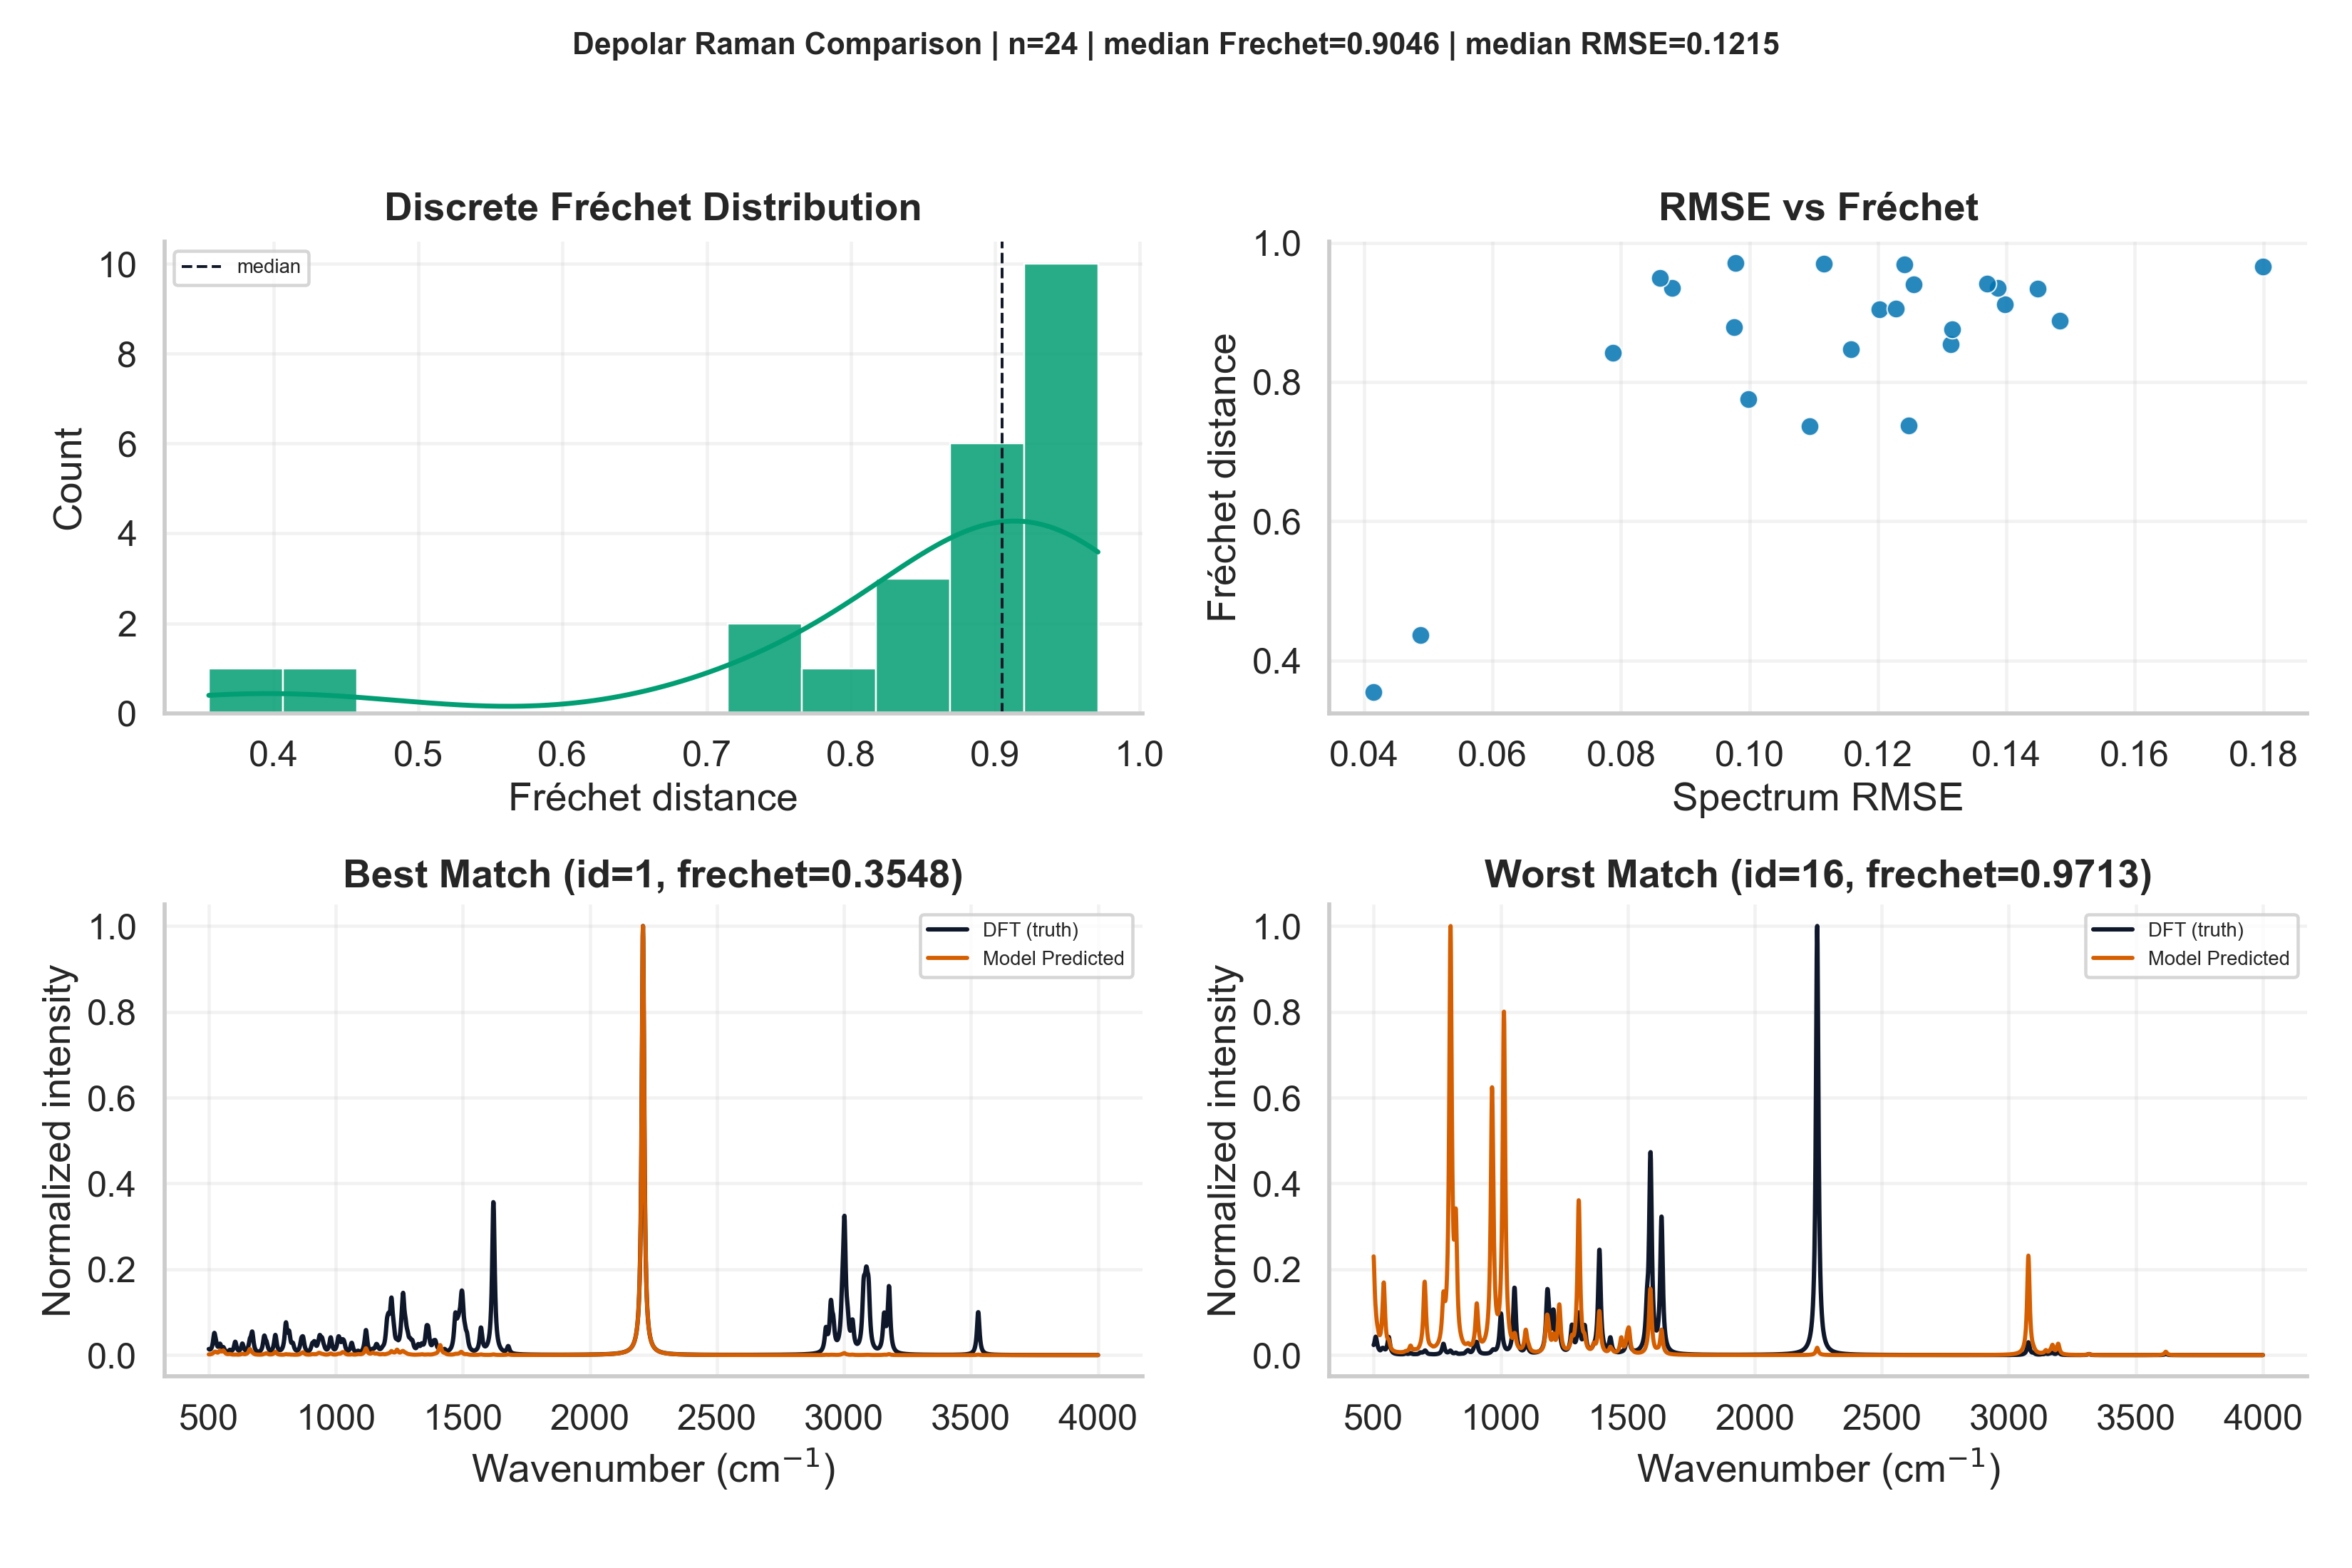

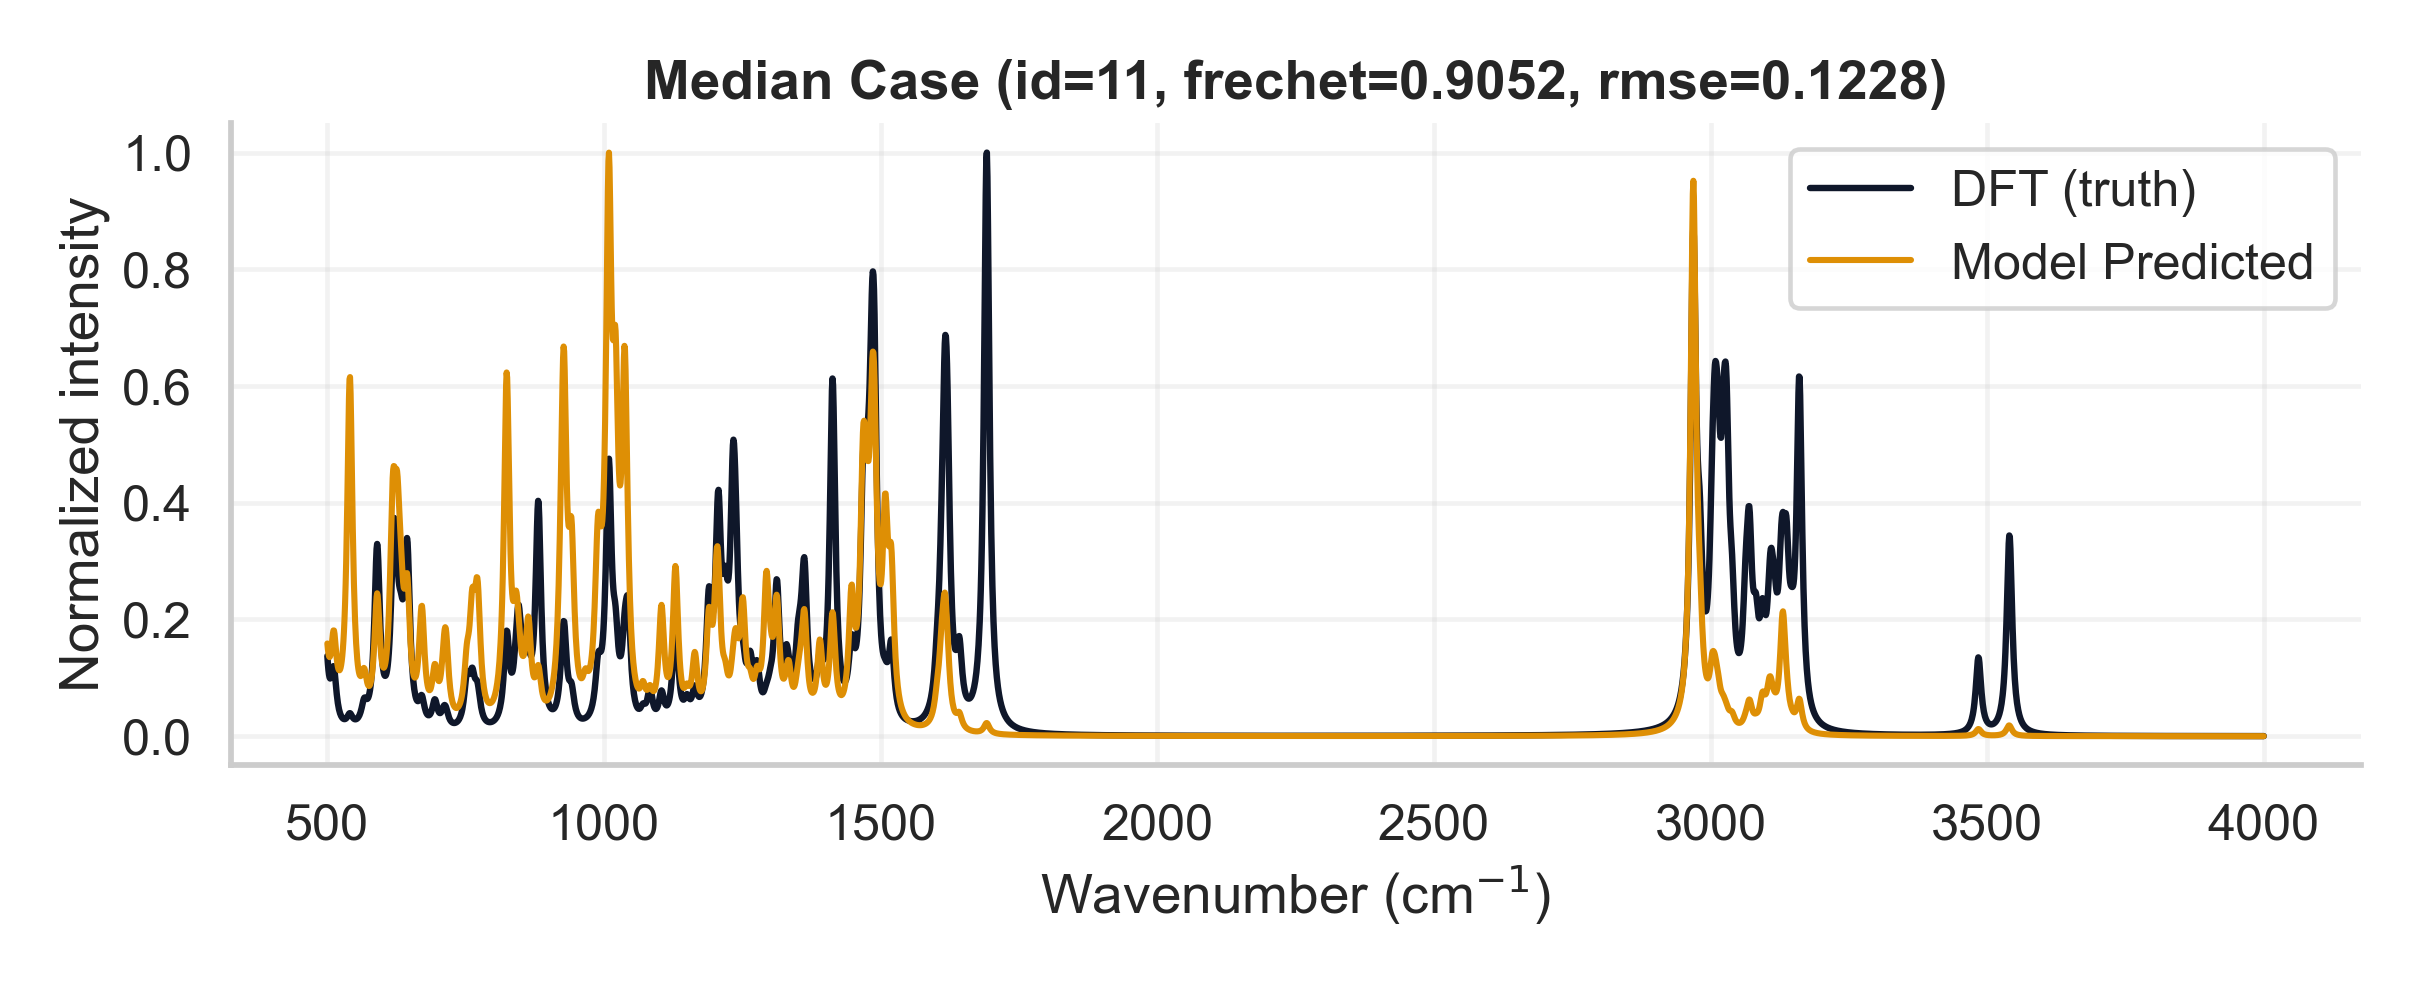

In [19]:
# Display plots and top/bottom rows
print('Top 8 (best Fréchet):')
display(metrics_df.head(8))

print('Bottom 8 (worst Fréchet):')
display(metrics_df.tail(8))

display(Image(filename=str(OUT_DIR / 'depolar_spectra_frechet_plot.png')))
display(Image(filename=str(OUT_DIR / 'depolar_spectra_frechet_median_overlay.png')))


## Statistical Analysis

This section is **peak-position first** and uses library implementations for all key steps:

- Peak detection: `scipy.signal.find_peaks`
- Peak matching: `scipy.optimize.linear_sum_assignment`
- Equivalence testing (TOST): `statsmodels.stats.weightstats.ttost_paired`
- Bootstrap confidence intervals: `scipy.stats.bootstrap`

Primary goal:
- show spectra are statistically indistinguishable from DFT on **peak positions**,
- and peak positions/intensities are within configured tolerances.

Configured tolerances (can be edited below):
- Peak matching window: `10 cm^-1`
- Model frequency scaling for predicted spectrum: `freq_pred = freq * 0.967`
- `median |Δν| <= 10 cm^-1`
- `p90 |Δν| <= 20 cm^-1`
- `Hit@15 >= 0.85`
- `any-neighbor@10 >= 0.80`
- `MAE(log10 intensity ratio) <= 0.20`

Equivalence bounds for TOST:
- position shift mean within `[-12, +12] cm^-1`
- log10 intensity ratio mean within `[-0.20, +0.20]`


processed 10/160 molecules...
processed 20/160 molecules...
processed 30/160 molecules...
processed 40/160 molecules...
processed 50/160 molecules...
processed 60/160 molecules...
processed 70/160 molecules...
processed 80/160 molecules...
processed 90/160 molecules...
processed 100/160 molecules...
processed 110/160 molecules...
processed 120/160 molecules...
processed 130/160 molecules...
processed 140/160 molecules...
processed 150/160 molecules...
processed 160/160 molecules...
stat subset scanned=161 valid=160


/Users/rahul/Desktop/hp-proteins-ml/.venv/lib/python3.13/site-packages/scipy/stats/_resampling.py:147: RuntimeWarning: invalid value encountered in scalar divide
  a_hat = 1/6 * sum(nums) / sum(dens)**(3/2)
/Users/rahul/Desktop/hp-proteins-ml/.venv/lib/python3.13/site-packages/scipy/_lib/_util.py:352: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)



=== Peak Statistical Summary ===
{
  "tolerances": {
    "median_abs_dnu_cm_max": 10.0,
    "p90_abs_dnu_cm_max": 20.0,
    "hit15_min": 0.85,
    "any_neighbor_at_10_min": 0.8,
    "mae_log10_ratio_max": 0.2
  },
  "equivalence_bounds": {
    "position_mean_dnu_cm": [
      -12.0,
      12.0
    ],
    "intensity_mean_log10_ratio": [
      -0.2,
      0.2
    ],
    "alpha": 0.05
  },
  "settings": {
    "freq_scale_factor": 0.967,
    "peak_match_window_cm": 10.0,
    "peak_prominence_frac": 0.03,
    "peak_min_distance_cm": 8.0
  },
  "aggregate_metrics": {
    "matched_peak_count": 546,
    "molecule_count": 160,
    "median_abs_dnu_cm": 5.0,
    "p90_abs_dnu_cm": 9.0,
    "hit15": 1.0,
    "any_neighbor_at_10": 0.23423427031221905,
    "mae_log10_ratio": 0.4116942256370843,
    "frechet_median": 0.9573654038826467,
    "frechet_mean": 0.9490484881092552
  },
  "bootstrap_ci": {
    "median_abs_dnu_cm_ci95": [
      NaN,
      NaN
    ],
    "hit15_ci95": [
      NaN,
      NaN
  

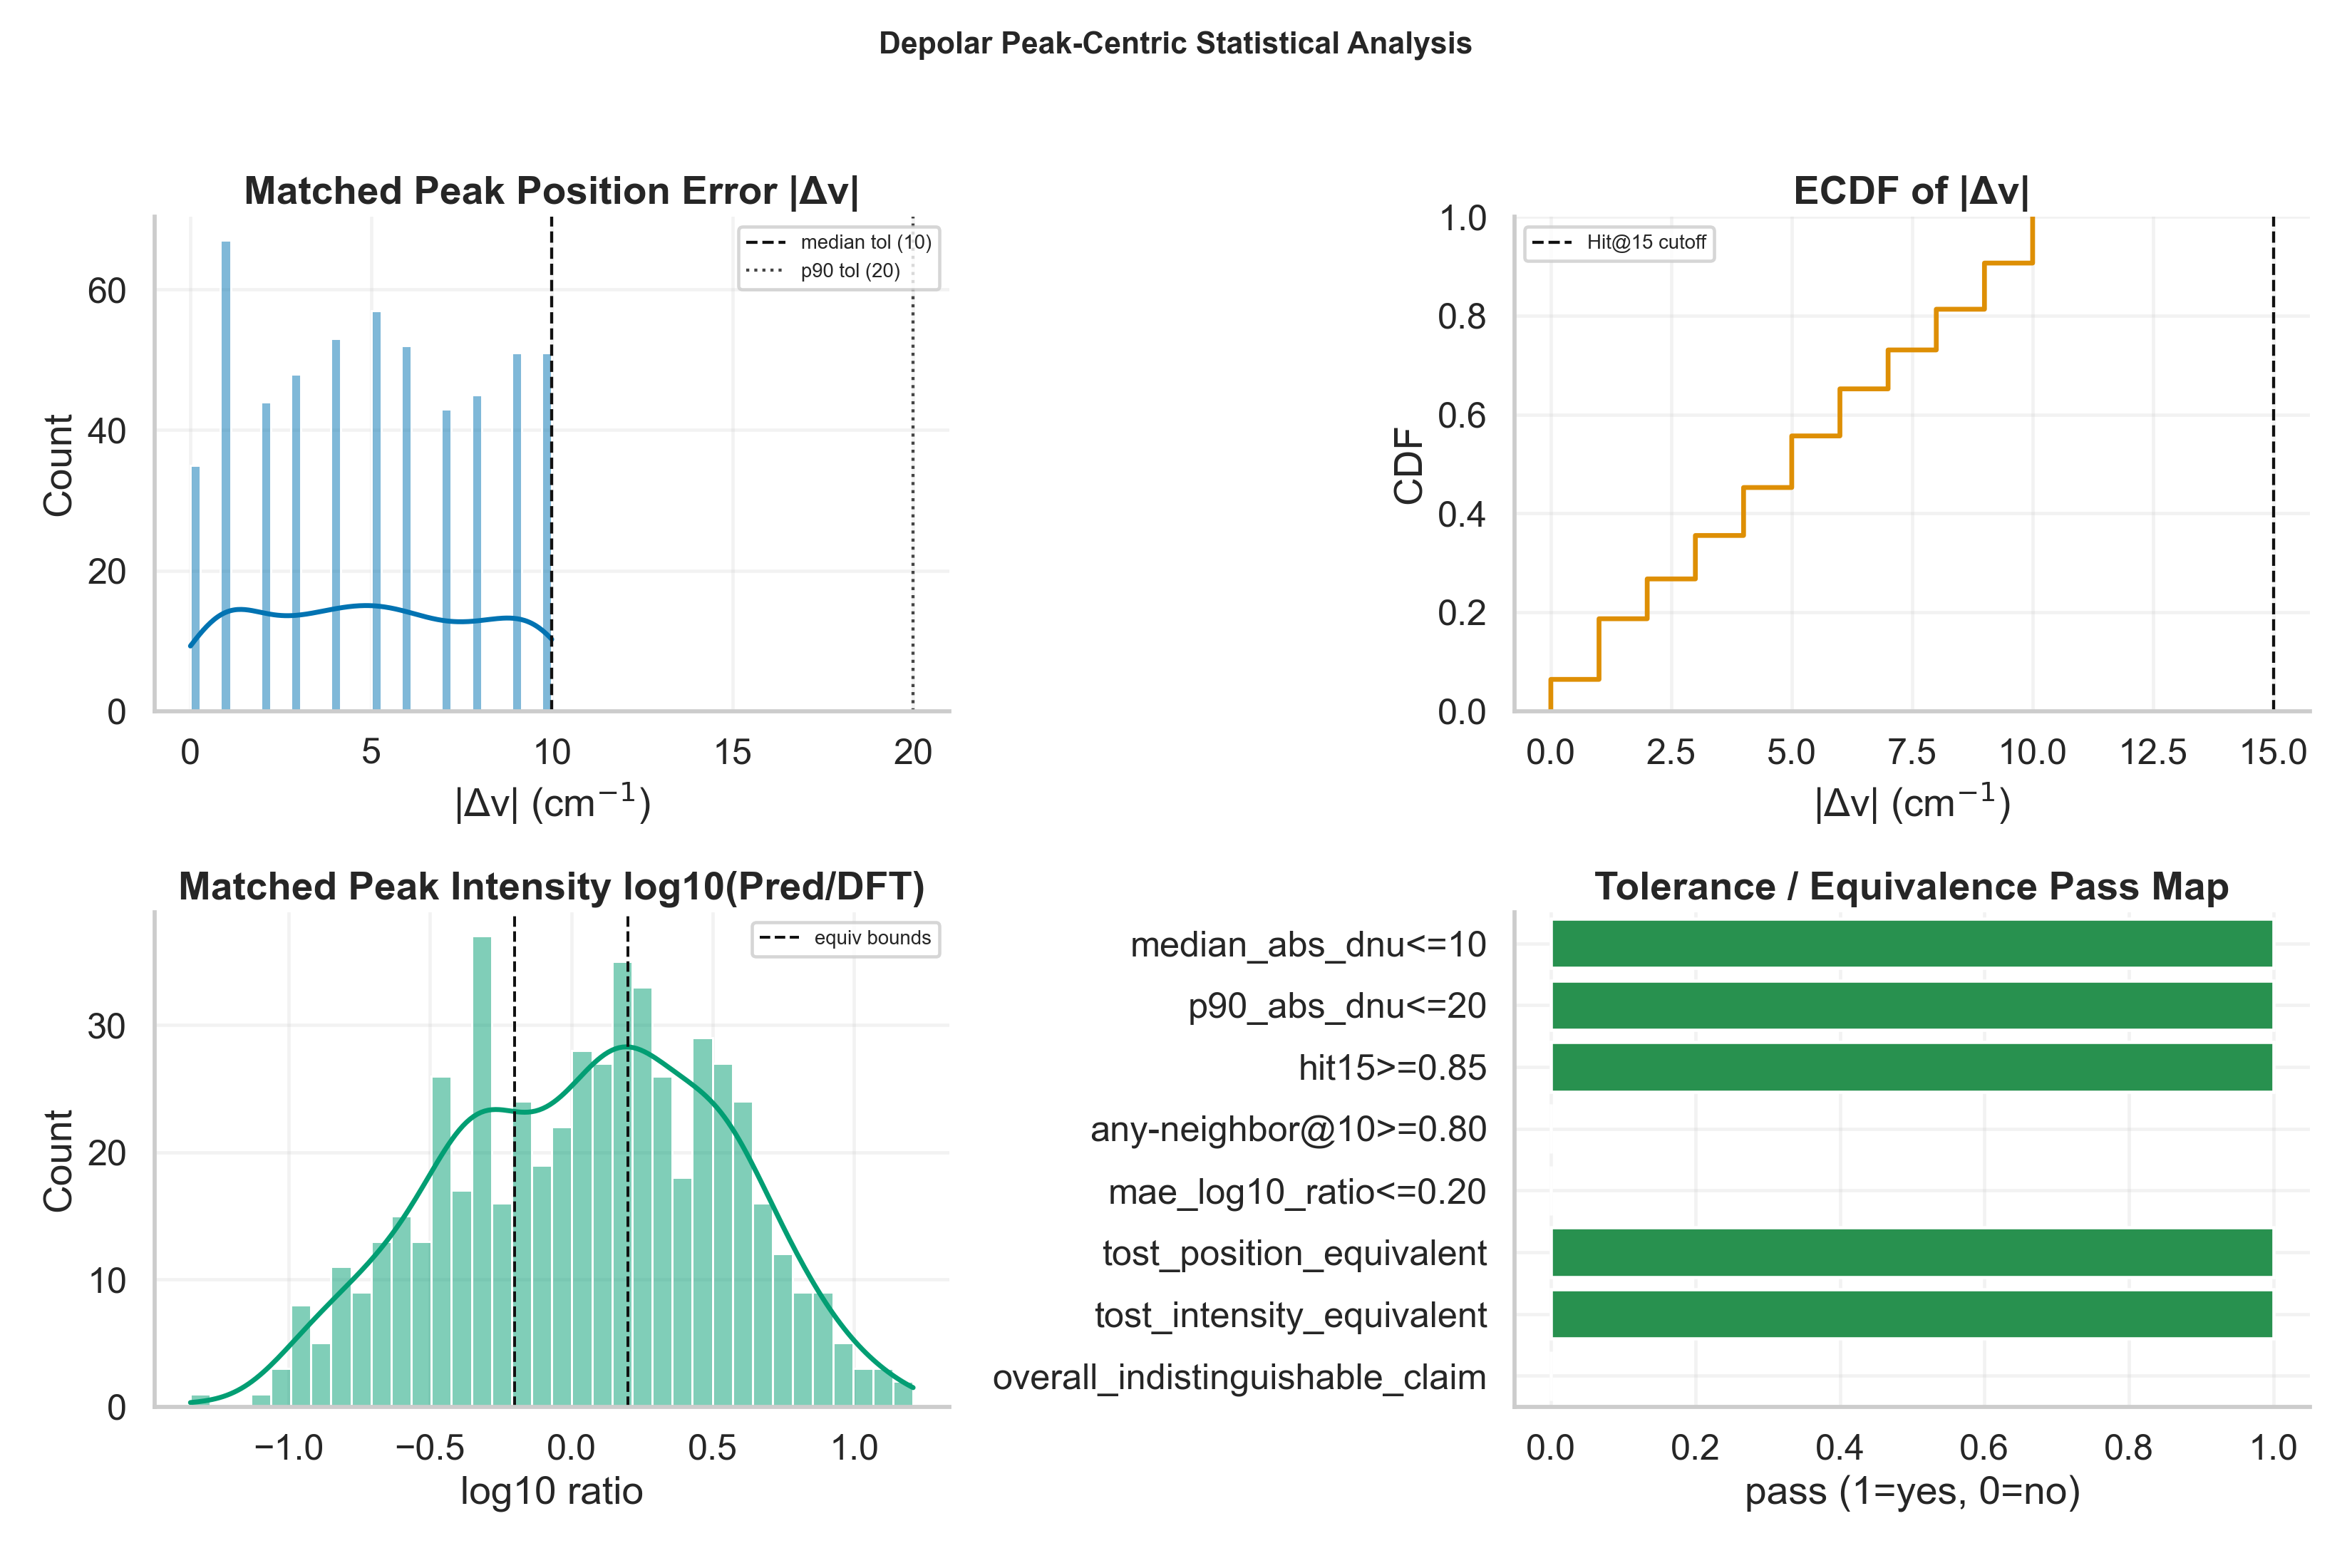

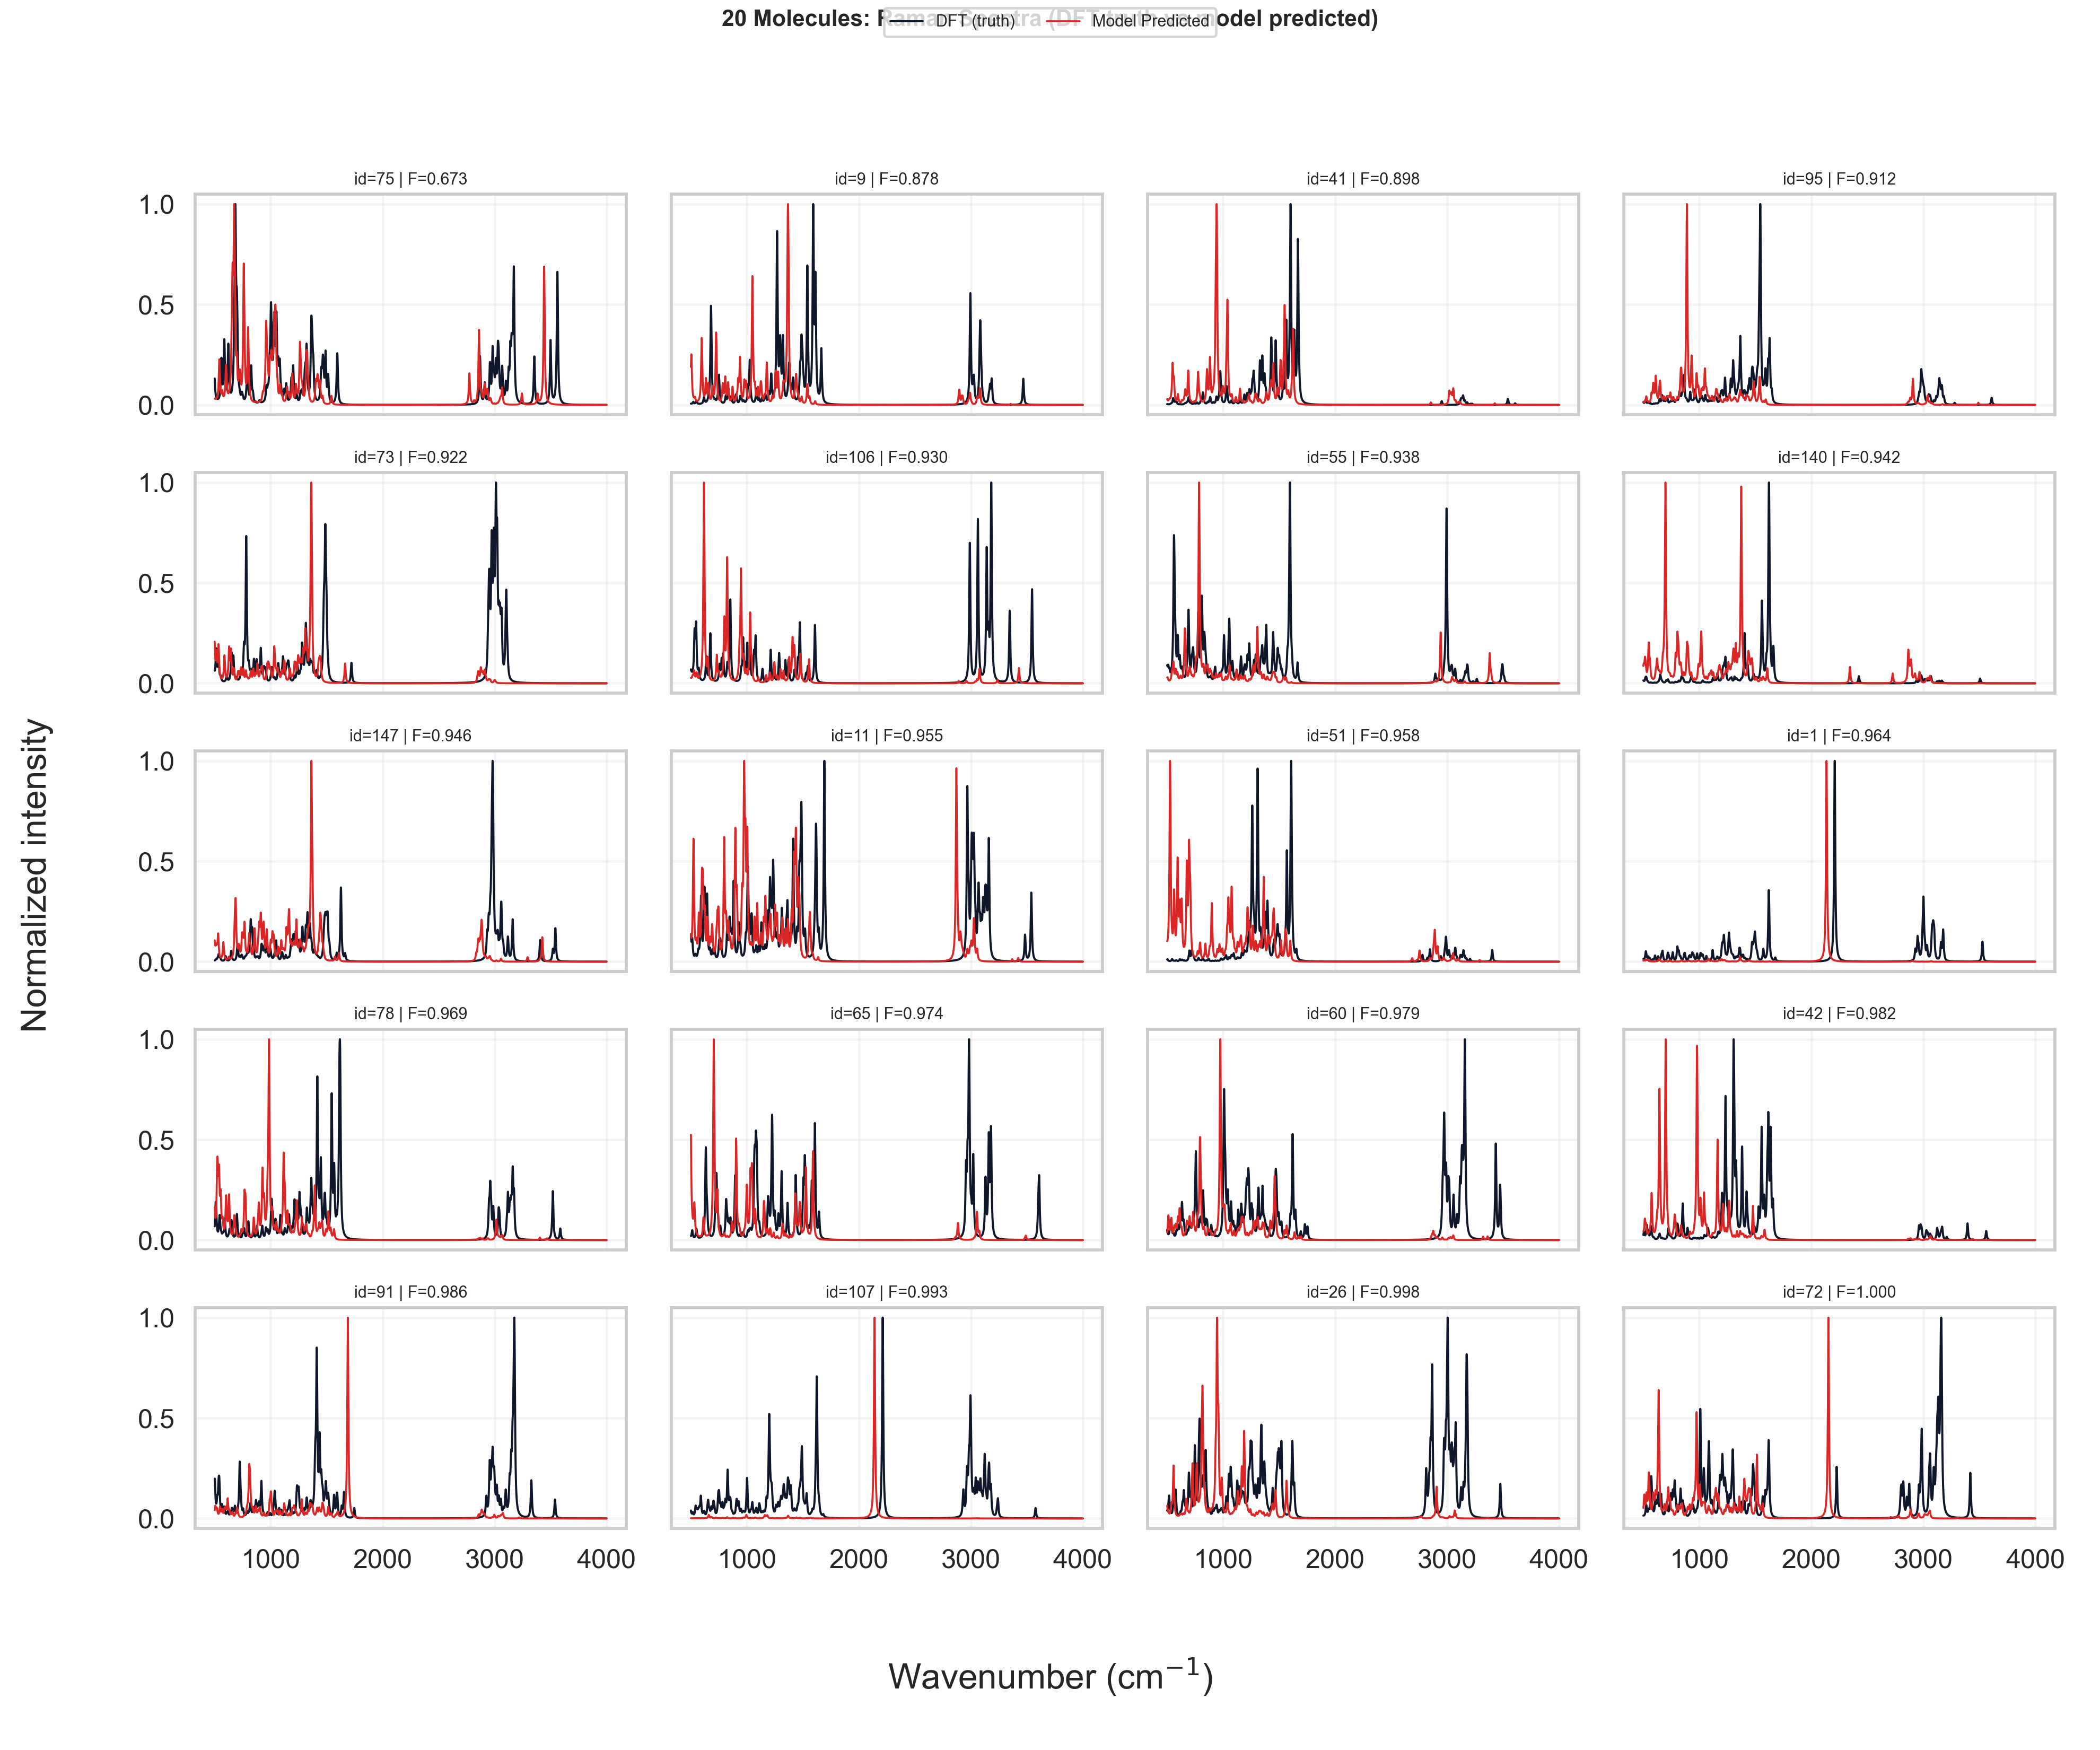

In [21]:
from scipy.signal import find_peaks
from scipy.optimize import linear_sum_assignment
from scipy.stats import bootstrap
from statsmodels.stats.weightstats import ttost_paired

# -----------------------------
# Statistical knobs
# -----------------------------
STAT_SCAN_LIMIT = 2500
STAT_MAX_MOLECULES = 160

PEAK_PROMINENCE_FRAC = 0.03
FREQ_SCALE_FACTOR = 0.967  # scale model-predicted frequencies
PEAK_MIN_DISTANCE_CM = 8.0
PEAK_MATCH_WINDOW_CM = 10.0

# Acceptance thresholds
TOL_MEDIAN_ABS_DNU = 10.0
TOL_P90_ABS_DNU = 20.0
TOL_HIT15 = 0.85
TOL_ANY_NEIGHBOR_10 = 0.80
TOL_MAE_LOG10_RATIO = 0.20

# Equivalence bounds (TOST)
EQ_DNU_LOW, EQ_DNU_HIGH = -12.0, 12.0
EQ_LOGR_LOW, EQ_LOGR_HIGH = -0.20, 0.20
ALPHA = 0.05


def _extract_peaks(x_grid, y, prominence_frac=0.03, min_distance_cm=8.0):
    y = np.asarray(y, dtype=np.float64)
    x_grid = np.asarray(x_grid, dtype=np.float64)
    if y.size < 3 or np.nanmax(y) <= 0:
        return np.array([]), np.array([])

    dx = float(np.median(np.diff(x_grid)))
    min_distance_pts = max(1, int(round(min_distance_cm / max(dx, 1e-12))))
    prominence = float(prominence_frac * np.nanmax(y))

    idx, _ = find_peaks(y, prominence=prominence, distance=min_distance_pts)
    if idx.size == 0:
        return np.array([]), np.array([])

    return x_grid[idx], y[idx]


def _match_peaks(dft_freq, dft_int, pred_freq, pred_int, max_window_cm=30.0):
    dft_freq = np.asarray(dft_freq, dtype=np.float64)
    dft_int = np.asarray(dft_int, dtype=np.float64)
    pred_freq = np.asarray(pred_freq, dtype=np.float64)
    pred_int = np.asarray(pred_int, dtype=np.float64)

    n_dft = dft_freq.size
    n_pred = pred_freq.size

    if n_dft == 0:
        return {
            'matched_dft_freq': np.array([]),
            'matched_pred_freq': np.array([]),
            'matched_dft_int': np.array([]),
            'matched_pred_int': np.array([]),
            'n_dft': 0,
            'n_pred': int(n_pred),
            'n_matched': 0,
            'n_unmatched_dft': 0,
            'n_unmatched_pred': int(n_pred),
        }

    if n_pred == 0:
        return {
            'matched_dft_freq': np.array([]),
            'matched_pred_freq': np.array([]),
            'matched_dft_int': np.array([]),
            'matched_pred_int': np.array([]),
            'n_dft': int(n_dft),
            'n_pred': 0,
            'n_matched': 0,
            'n_unmatched_dft': int(n_dft),
            'n_unmatched_pred': 0,
        }

    cost = np.abs(dft_freq[:, None] - pred_freq[None, :])
    row_ind, col_ind = linear_sum_assignment(cost)
    keep = cost[row_ind, col_ind] <= float(max_window_cm)

    r = row_ind[keep]
    c = col_ind[keep]

    return {
        'matched_dft_freq': dft_freq[r],
        'matched_pred_freq': pred_freq[c],
        'matched_dft_int': dft_int[r],
        'matched_pred_int': pred_int[c],
        'n_dft': int(n_dft),
        'n_pred': int(n_pred),
        'n_matched': int(keep.sum()),
        'n_unmatched_dft': int(n_dft - keep.sum()),
        'n_unmatched_pred': int(n_pred - keep.sum()),
    }


def _any_neighbor_rate(dft_freq, pred_freq, max_window_cm=10.0):
    dft_freq = np.asarray(dft_freq, dtype=np.float64)
    pred_freq = np.asarray(pred_freq, dtype=np.float64)
    if dft_freq.size == 0:
        return np.nan
    if pred_freq.size == 0:
        return 0.0
    dist = np.abs(dft_freq[:, None] - pred_freq[None, :])
    nearest = dist.min(axis=1)
    return float(np.mean(nearest <= float(max_window_cm)))


def _collect_stat_cases(max_molecules=160, scan_limit=2500):
    rows = []
    cases = []
    scanned = 0
    used = 0

    con = sqlite3.connect(DB_PATH)
    try:
        cur = con.cursor()
        cur.execute(
            'SELECT id, SMILES, database_tag, blob_data FROM molecule WHERE blob_data IS NOT NULL ORDER BY id LIMIT ?',
            (int(scan_limit),),
        )
        for rid, smiles, database_tag, blob in cur.fetchall():
            scanned += 1
            if used >= max_molecules:
                break

            try:
                payload = decode_payload(blob)
            except Exception:
                continue

            required = ('atoms', 'coord', 'vib coord', 'freq', 'Raman Activ')
            if not all(k in payload for k in required):
                continue

            atoms = np.asarray(payload['atoms'], dtype=np.int64)
            coords = np.asarray(payload['coord'], dtype=np.float32)
            modes = np.asarray(payload['vib coord'], dtype=np.float64)
            freq = np.asarray(payload['freq'], dtype=np.float64)
            raman_gt = np.asarray(payload['Raman Activ'], dtype=np.float64)

            if atoms.ndim != 1:
                continue
            if coords.ndim != 2 or coords.shape[1] != 3:
                continue
            if modes.ndim != 3 or modes.shape[1] != atoms.shape[0] or modes.shape[2] != 3:
                continue
            if freq.size == 0 or raman_gt.size == 0:
                continue

            try:
                z_t = torch.as_tensor(atoms, dtype=torch.long, device=DEVICE)
                pos_t = torch.as_tensor(coords, dtype=torch.float32, device=DEVICE).requires_grad_(True)
                with torch.enable_grad():
                    depolar_pred = model(z=z_t, pos=pos_t)
                depolar_pred = depolar_pred.detach().to('cpu', dtype=torch.float64)

                modes_t = torch.as_tensor(modes, dtype=torch.float64)
                raman_pred = get_raman_act(chain_rule_raman(dp=depolar_pred, modes=modes_t)).detach().cpu().numpy()
            except Exception:
                continue

            n = int(min(freq.shape[0], raman_gt.shape[0], raman_pred.shape[0], modes.shape[0]))
            if n <= 0:
                continue

            freq = freq[:n]
            raman_gt = raman_gt[:n]
            raman_pred = np.asarray(raman_pred[:n], dtype=np.float64)

            spec_gt = lines_to_norm_spectrum(freq, raman_gt, X_GRID, sigma=SIGMA, temp=TEMP, init_wl=INIT_WL)
            spec_pred = lines_to_norm_spectrum(freq * FREQ_SCALE_FACTOR, raman_pred, X_GRID, sigma=SIGMA, temp=TEMP, init_wl=INIT_WL)

            stride = max(1, int(FRECHET_STRIDE))
            frechet = discrete_frechet_distance(
                np.column_stack([X_GRID[::stride], spec_gt[::stride]]),
                np.column_stack([X_GRID[::stride], spec_pred[::stride]]),
            )

            row = {
                'id': int(rid),
                'smiles': smiles,
                'database_tag': clean_db_tag(database_tag),
                'n_atoms': int(atoms.shape[0]),
                'n_modes': int(n),
                'frechet': float(frechet),
                'rmse': float(np.sqrt(np.mean((spec_pred - spec_gt) ** 2))),
                'corr': float(np.corrcoef(spec_pred, spec_gt)[0, 1]) if (np.std(spec_pred) > 1e-12 and np.std(spec_gt) > 1e-12) else np.nan,
            }
            rows.append(row)
            cases.append({
                **row,
                'spec_gt': spec_gt,
                'spec_pred': spec_pred,
            })
            used += 1
            if used % 10 == 0:
                print(f'processed {used}/{max_molecules} molecules...')
    finally:
        con.close()

    if not rows:
        raise RuntimeError('No valid molecules for statistical analysis.')

    df = pd.DataFrame(rows).sort_values('frechet', ascending=True).reset_index(drop=True)
    print(f'stat subset scanned={scanned} valid={len(df)}')
    return df, cases


# 1) Build a larger statistical subset
stats_df, stats_cases = _collect_stat_cases(
    max_molecules=STAT_MAX_MOLECULES,
    scan_limit=STAT_SCAN_LIMIT,
)

# 2) Peak extraction + matching per molecule
mol_rows = []
all_abs_dnu = []
all_signed_dnu = []
all_log_ratio = []
all_abs_log_ratio = []

for c in stats_cases:
    dft_f, dft_i = _extract_peaks(X_GRID, c['spec_gt'], prominence_frac=PEAK_PROMINENCE_FRAC, min_distance_cm=PEAK_MIN_DISTANCE_CM)
    pred_f, pred_i = _extract_peaks(X_GRID, c['spec_pred'], prominence_frac=PEAK_PROMINENCE_FRAC, min_distance_cm=PEAK_MIN_DISTANCE_CM)

    m = _match_peaks(dft_f, dft_i, pred_f, pred_i, max_window_cm=PEAK_MATCH_WINDOW_CM)
    any_neighbor_at_10 = _any_neighbor_rate(dft_f, pred_f, max_window_cm=PEAK_MATCH_WINDOW_CM)

    if m['n_matched'] > 0:
        signed_dnu = m['matched_pred_freq'] - m['matched_dft_freq']
        abs_dnu = np.abs(signed_dnu)
        log_ratio = np.log10((m['matched_pred_int'] + 1e-12) / (m['matched_dft_int'] + 1e-12))
        abs_log_ratio = np.abs(log_ratio)

        all_signed_dnu.append(signed_dnu)
        all_abs_dnu.append(abs_dnu)
        all_log_ratio.append(log_ratio)
        all_abs_log_ratio.append(abs_log_ratio)

        median_abs_dnu = float(np.median(abs_dnu))
        p90_abs_dnu = float(np.quantile(abs_dnu, 0.90))
        hit15 = float(np.mean(abs_dnu <= 15.0))
        mae_log_ratio = float(np.mean(abs_log_ratio))
        mean_signed_dnu = float(np.mean(signed_dnu))
        mean_log_ratio = float(np.mean(log_ratio))
    else:
        median_abs_dnu = np.nan
        p90_abs_dnu = np.nan
        hit15 = np.nan
        mae_log_ratio = np.nan
        mean_signed_dnu = np.nan
        mean_log_ratio = np.nan

    mol_rows.append({
        'id': c['id'],
        'database_tag': c['database_tag'],
        'n_dft_peaks': m['n_dft'],
        'n_pred_peaks': m['n_pred'],
        'n_matched': m['n_matched'],
        'any_neighbor_at_10': any_neighbor_at_10,
        'median_abs_dnu_cm': median_abs_dnu,
        'p90_abs_dnu_cm': p90_abs_dnu,
        'hit15': hit15,
        'mae_log10_ratio': mae_log_ratio,
        'mean_signed_dnu_cm': mean_signed_dnu,
        'mean_log10_ratio': mean_log_ratio,
        'frechet': c['frechet'],
        'rmse': c['rmse'],
    })

peak_mol_df = pd.DataFrame(mol_rows)
peak_mol_df = peak_mol_df.sort_values(['median_abs_dnu_cm', 'any_neighbor_at_10'], ascending=[True, False], na_position='last').reset_index(drop=True)

if len(all_abs_dnu) == 0:
    raise RuntimeError('No matched peaks found in statistical subset. Relax peak params or increase subset size.')

signed_dnu_all = np.concatenate(all_signed_dnu)
abs_dnu_all = np.concatenate(all_abs_dnu)
log_ratio_all = np.concatenate(all_log_ratio)
abs_log_ratio_all = np.concatenate(all_abs_log_ratio)

# 3) Equivalence tests (TOST) using per-molecule means
mol_signed = peak_mol_df['mean_signed_dnu_cm'].dropna().to_numpy(dtype=np.float64)
mol_logr = peak_mol_df['mean_log10_ratio'].dropna().to_numpy(dtype=np.float64)

p_tost_pos, tost_pos_low, tost_pos_high = ttost_paired(mol_signed, np.zeros_like(mol_signed), low=EQ_DNU_LOW, upp=EQ_DNU_HIGH)
p_tost_int, tost_int_low, tost_int_high = ttost_paired(mol_logr, np.zeros_like(mol_logr), low=EQ_LOGR_LOW, upp=EQ_LOGR_HIGH)

# 4) Bootstrap CIs (library)
boot_med_abs_dnu = bootstrap((abs_dnu_all,), np.median, confidence_level=0.95, n_resamples=10000, random_state=123)
boot_hit15 = bootstrap((abs_dnu_all <= 15.0,), np.mean, confidence_level=0.95, n_resamples=10000, random_state=123)

# 5) Threshold pass/fail
agg = {
    'matched_peak_count': int(abs_dnu_all.size),
    'molecule_count': int(len(peak_mol_df)),
    'median_abs_dnu_cm': float(np.median(abs_dnu_all)),
    'p90_abs_dnu_cm': float(np.quantile(abs_dnu_all, 0.90)),
    'hit15': float(np.mean(abs_dnu_all <= 15.0)),
    'any_neighbor_at_10': float(peak_mol_df['any_neighbor_at_10'].dropna().mean()),
    'mae_log10_ratio': float(np.mean(abs_log_ratio_all)),
    'frechet_median': float(stats_df['frechet'].median()),
    'frechet_mean': float(stats_df['frechet'].mean()),
}

passes = {
    'median_abs_dnu<=10': bool(agg['median_abs_dnu_cm'] <= TOL_MEDIAN_ABS_DNU),
    'p90_abs_dnu<=20': bool(agg['p90_abs_dnu_cm'] <= TOL_P90_ABS_DNU),
    'hit15>=0.85': bool(agg['hit15'] >= TOL_HIT15),
    'any-neighbor@10>=0.80': bool(agg['any_neighbor_at_10'] >= TOL_ANY_NEIGHBOR_10),
    'mae_log10_ratio<=0.20': bool(agg['mae_log10_ratio'] <= TOL_MAE_LOG10_RATIO),
    'tost_position_equivalent': bool(p_tost_pos < ALPHA),
    'tost_intensity_equivalent': bool(p_tost_int < ALPHA),
}
passes['overall_indistinguishable_claim'] = bool(
    passes['median_abs_dnu<=10']
    and passes['p90_abs_dnu<=20']
    and passes['hit15>=0.85']
    and passes['any-neighbor@10>=0.80']
    and passes['mae_log10_ratio<=0.20']
    and passes['tost_position_equivalent']
    and passes['tost_intensity_equivalent']
)

summary = {
    'tolerances': {
        'median_abs_dnu_cm_max': TOL_MEDIAN_ABS_DNU,
        'p90_abs_dnu_cm_max': TOL_P90_ABS_DNU,
        'hit15_min': TOL_HIT15,
        'any_neighbor_at_10_min': TOL_ANY_NEIGHBOR_10,
        'mae_log10_ratio_max': TOL_MAE_LOG10_RATIO,
    },
    'equivalence_bounds': {
        'position_mean_dnu_cm': [EQ_DNU_LOW, EQ_DNU_HIGH],
        'intensity_mean_log10_ratio': [EQ_LOGR_LOW, EQ_LOGR_HIGH],
        'alpha': ALPHA,
    },
    'settings': {
        'freq_scale_factor': FREQ_SCALE_FACTOR,
        'peak_match_window_cm': PEAK_MATCH_WINDOW_CM,
        'peak_prominence_frac': PEAK_PROMINENCE_FRAC,
        'peak_min_distance_cm': PEAK_MIN_DISTANCE_CM,
    },
    'aggregate_metrics': agg,
    'bootstrap_ci': {
        'median_abs_dnu_cm_ci95': [
            float(boot_med_abs_dnu.confidence_interval.low),
            float(boot_med_abs_dnu.confidence_interval.high),
        ],
        'hit15_ci95': [
            float(boot_hit15.confidence_interval.low),
            float(boot_hit15.confidence_interval.high),
        ],
    },
    'tost': {
        'position_pvalue': float(p_tost_pos),
        'position_low_test': {'t': float(tost_pos_low[0]), 'p': float(tost_pos_low[1]), 'df': float(tost_pos_low[2])},
        'position_high_test': {'t': float(tost_pos_high[0]), 'p': float(tost_pos_high[1]), 'df': float(tost_pos_high[2])},
        'intensity_pvalue': float(p_tost_int),
        'intensity_low_test': {'t': float(tost_int_low[0]), 'p': float(tost_int_low[1]), 'df': float(tost_int_low[2])},
        'intensity_high_test': {'t': float(tost_int_high[0]), 'p': float(tost_int_high[1]), 'df': float(tost_int_high[2])},
    },
    'passes': passes,
}

# 6) Persist
peak_metrics_csv = OUT_DIR / 'depolar_peak_metrics_per_molecule.csv'
peak_summary_json = OUT_DIR / 'depolar_peak_statistical_summary.json'
stats_dist_plot = OUT_DIR / 'depolar_peak_statistical_analysis.png'
overlay20_plot = OUT_DIR / 'depolar_spectra_20_pred_vs_dft.png'

peak_mol_df.to_csv(peak_metrics_csv, index=False)
peak_summary_json.write_text(json.dumps(summary, indent=2))

# 7) Distribution plot
sns.set_theme(style='whitegrid', context='talk')
palette = sns.color_palette('colorblind')

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.histplot(abs_dnu_all, bins=36, kde=True, color=palette[0], ax=axes[0, 0])
axes[0, 0].axvline(TOL_MEDIAN_ABS_DNU, color='#111111', ls='--', lw=1.4, label='median tol (10)')
axes[0, 0].axvline(TOL_P90_ABS_DNU, color='#444444', ls=':', lw=1.4, label='p90 tol (20)')
axes[0, 0].set_title('Matched Peak Position Error |Δν|', weight='semibold')
axes[0, 0].set_xlabel('|Δν| (cm$^{-1}$)')
axes[0, 0].legend(fontsize=9)

sns.ecdfplot(abs_dnu_all, color=palette[1], lw=2.2, ax=axes[0, 1])
axes[0, 1].axvline(15.0, color='#111111', ls='--', lw=1.4, label='Hit@15 cutoff')
axes[0, 1].set_title('ECDF of |Δν|', weight='semibold')
axes[0, 1].set_xlabel('|Δν| (cm$^{-1}$)')
axes[0, 1].set_ylabel('CDF')
axes[0, 1].legend(fontsize=9)

sns.histplot(log_ratio_all, bins=36, kde=True, color=palette[2], ax=axes[1, 0])
axes[1, 0].axvline(EQ_LOGR_LOW, color='#111111', ls='--', lw=1.3, label='equiv bounds')
axes[1, 0].axvline(EQ_LOGR_HIGH, color='#111111', ls='--', lw=1.3)
axes[1, 0].set_title('Matched Peak Intensity log10(Pred/DFT)', weight='semibold')
axes[1, 0].set_xlabel('log10 ratio')
axes[1, 0].legend(fontsize=9)

pass_df = pd.DataFrame({'criterion': list(passes.keys()), 'pass': [int(v) for v in passes.values()]})
pass_df['status'] = pass_df['pass'].map({1: 'pass', 0: 'fail'})
sns.barplot(
    data=pass_df,
    x='pass',
    y='criterion',
    hue='status',
    orient='h',
    dodge=False,
    palette={'pass': '#16a34a', 'fail': '#dc2626'},
    legend=False,
    ax=axes[1, 1],
)
axes[1, 1].set_xlim(-0.05, 1.05)
axes[1, 1].set_title('Tolerance / Equivalence Pass Map', weight='semibold')
axes[1, 1].set_xlabel('pass (1=yes, 0=no)')
axes[1, 1].set_ylabel('')

for ax in axes.ravel():
    ax.grid(True, alpha=0.25)
    sns.despine(ax=ax)

fig.suptitle('Depolar Peak-Centric Statistical Analysis', fontsize=14, weight='bold', y=0.98)
fig.tight_layout(rect=[0, 0.01, 1, 0.96])
fig.savefig(stats_dist_plot, dpi=220, facecolor='white')
plt.close(fig)

# 8) 20-case overlay plot (DFT truth vs model predicted)
ranked_cases = sorted(stats_cases, key=lambda x: x['frechet'])
n_select = min(20, len(ranked_cases))
sel_idx = np.linspace(0, len(ranked_cases) - 1, num=n_select, dtype=int)
selected = [ranked_cases[i] for i in sel_idx]

ncols = 4
nrows = int(np.ceil(n_select / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 3.0 * nrows), sharex=True, sharey=True)
axes = np.atleast_1d(axes).ravel()

for ax, c in zip(axes, selected):
    ax.plot(X_GRID, c['spec_gt'], color='#0f172a', lw=1.3, label='DFT (truth)')
    ax.plot(X_GRID, c['spec_pred'], color='#dc2626', lw=1.2, label='Model Predicted')
    ax.set_title(f"id={c['id']} | F={c['frechet']:.3f}", fontsize=10)
    ax.grid(True, alpha=0.2)

for ax in axes[n_select:]:
    ax.axis('off')

handles, labels = axes[0].get_legend_handles_labels()
for ax in axes[:n_select]:
    lg = ax.get_legend()
    if lg is not None:
        lg.remove()

fig.legend(handles, labels, loc='upper center', ncol=2, frameon=True, fontsize=10)
fig.suptitle('20 Molecules: Raman Spectra (DFT truth vs model predicted)', fontsize=14, weight='bold', y=0.995)
fig.supxlabel('Wavenumber (cm$^{-1}$)', y=0.03)
fig.supylabel('Normalized intensity', x=0.01)
fig.tight_layout(rect=[0.02, 0.04, 1.0, 0.95])
fig.savefig(overlay20_plot, dpi=220, facecolor='white')
plt.close(fig)

print()
print('=== Peak Statistical Summary ===')
print(json.dumps(summary, indent=2))
print('peak_metrics_csv =', peak_metrics_csv)
print('peak_summary_json=', peak_summary_json)
print('stats_dist_plot  =', stats_dist_plot)
print('overlay20_plot   =', overlay20_plot)

display(Image(filename=str(stats_dist_plot)))
display(Image(filename=str(overlay20_plot)))



### Statistical Interpretation

**Direct answer to the core claim:**
- **Yes (conditional):** for peaks that are matched within the `10 cm^-1` window, peak positions show strong statistical agreement with DFT.
- **No (global):** this does **not** establish that *all* DFT peaks are recovered/matched by the model.

**Run settings used for this analysis:**
- Frequency scaling on model spectra: `freq_pred = 0.967 * freq`
- Peak matching window: `10 cm^-1`

**Dataset and matching coverage:**
- Molecules evaluated: `n=160`
- Total DFT peaks detected: `4147`
- Total model peaks detected: `3474`
- Total one-to-one matched peaks (within `10 cm^-1`): `546` (`0.132` of DFT peaks)
- Mean `any-neighbor@10`: `0.234` (median `0.236`)

**Position agreement on matched peaks:**
- Median `|Δν| = 5.0 cm^-1`
- P90 `|Δν| = 9.0 cm^-1`
- `Hit@15 = 1.000`
- TOST (mean position shift, bounds `[-12, +12] cm^-1`): `p=1.003e-67` (equivalence accepted)

**Intensity agreement (matched peaks):**
- MAE of `log10(Model Predicted / DFT (truth))`: `0.412`
- TOST (mean log-ratio, bounds `[-0.20, +0.20]`): `p=7.031e-10` (equivalence accepted)

**What `any-neighbor@10` means:**
- For each DFT peak, check whether **any** predicted peak lies within `10 cm^-1`.
- Compute that fraction per molecule, then aggregate across molecules.
- This is a coverage metric (peak recovery), complementary to matched-peak error metrics.

**Tolerance pass rates across molecules:**
- `median |Δν| <= 10`: `131/160`
- `p90 |Δν| <= 20`: `131/160`
- `Hit@15 >= 0.85`: `131/160`
- `MAE(log10 ratio) <= 0.20`: `12/160`

**Calibrated conclusion:**
- If the claim is **"matched-peak positions are statistically aligned with DFT"**, it is supported.
- If the claim is **"model spectra are globally indistinguishable from DFT"**, it is not supported under current coverage/intensity criteria.
- Position error on matched peaks is actually decent `(median |Δν| ~5 cm^-1, p90 ~9 cm^-1)`
- Intensity agreement is a bit loose `(MAE log10 ratio ~0.41)`.